<a href="https://colab.research.google.com/github/anushavk416/Datascience-Tasks/blob/main/taxitrip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

### EDA

In [61]:
# read data
df = pd.read_csv("/content/taxi_trip_pricing.csv")
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [64]:
df.shape

(1000, 11)

In [63]:
df.drop_duplicates(inplace = True)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [66]:
# checking nulls
df.isnull().sum()
df[df['Trip_Distance_km'].isnull()]
# all nulls aren't present in the same records
# hence need to fill nulls

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
10,NaN,Morning,Weekday,4.0,NaN,Clear,2.40,0.58,0.43,26.34,14.8920
84,NaN,Night,Weekday,1.0,Medium,Clear,3.38,1.50,0.31,58.31,45.8161
87,NaN,NaN,Weekday,1.0,Medium,Clear,3.41,0.57,0.39,92.72,57.9476
95,NaN,Morning,Weekend,1.0,Medium,Clear,3.43,0.91,0.50,67.43,60.0770
111,NaN,Morning,Weekday,2.0,Low,Clear,4.01,1.65,0.17,109.77,37.3559
134,NaN,Afternoon,Weekend,3.0,Low,Clear,2.55,1.46,0.37,38.26,85.6182
137,NaN,NaN,NaN,3.0,Low,Clear,4.52,1.38,0.35,57.56,73.5870
142,NaN,Afternoon,Weekend,4.0,Medium,Rain,2.98,1.24,0.28,36.68,44.7092
166,NaN,Evening,Weekday,2.0,High,Clear,4.11,1.00,0.36,86.31,51.9016


In [67]:
# handling Trip_Distance_km
df['Trip_Distance_km'].unique()
df['Trip_Distance_km'].value_counts()
df['Trip_Distance_km'] = df['Trip_Distance_km'].fillna(df['Trip_Distance_km'].mean())
df['Trip_Distance_km'].isnull().sum()

np.int64(0)

In [68]:
# handling Time_of_Day
df['Time_of_Day'].unique()
df['Time_of_Day'] = df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])
df['Time_of_Day'].isnull().sum()

np.int64(0)

In [69]:
# handling Day_of_Week
df['Day_of_Week'].unique()
df['Day_of_Week'] = df['Day_of_Week'].fillna(df['Day_of_Week'].mode()[0])
df['Day_of_Week'].isnull().sum()

np.int64(0)

In [70]:
#handling Passenger_Count
df['Passenger_Count'].unique()
df['Passenger_Count'].value_counts()
df['Passenger_Count'] = df['Passenger_Count'].fillna(round(df['Passenger_Count'].mean()))
df['Passenger_Count'].isnull().sum()
df['Passenger_Count'] = df['Passenger_Count'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       1000 non-null   float64
 1   Time_of_Day            1000 non-null   object 
 2   Day_of_Week            1000 non-null   object 
 3   Passenger_Count        1000 non-null   int64  
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(6), int64(1), object(4)
memory usage: 86.1+ KB


In [71]:
# handling Traffic_Conditions
df['Traffic_Conditions'].value_counts()
df['Traffic_Conditions'] = df['Traffic_Conditions'].fillna(df['Traffic_Conditions'].mode()[0])
df['Traffic_Conditions'].isnull().sum()

np.int64(0)

In [72]:
# handling Weather
df['Weather'].value_counts()
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])
df['Weather'].isnull().sum()

np.int64(0)

In [73]:
# handling Base_Fare
df['Base_Fare'].unique()
df['Base_Fare'] = df['Base_Fare'].fillna(df['Base_Fare'].mean())
df['Base_Fare'].isnull().sum()

np.int64(0)

In [74]:
#handling Per_Km_Rate
df['Per_Km_Rate'].unique()
df['Per_Km_Rate'] = df['Per_Km_Rate'].fillna(df['Per_Km_Rate'].mean())
df['Per_Km_Rate'].isnull().sum()

np.int64(0)

In [75]:
#handling Per_Minute_Rate
df['Per_Minute_Rate'].unique()
df['Per_Minute_Rate'] = df['Per_Minute_Rate'].fillna(df['Per_Minute_Rate'].mean())
df['Per_Minute_Rate'].isnull().sum()

np.int64(0)

In [76]:
# handling Trip_Duration_Minutes
df['Trip_Duration_Minutes'].unique()
df['Trip_Duration_Minutes'] = df['Trip_Duration_Minutes'].fillna(df['Trip_Duration_Minutes'].mean())
df['Trip_Duration_Minutes'].isnull().sum()

np.int64(0)

In [77]:
# handling Trip_Price
df['Trip_Price'].unique()
df.dropna(inplace = True) #as it is target column
df.isnull().sum()
df.reset_index(inplace = True)
df.drop('index', axis = 1, inplace = True)
df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,Morning,Weekday,3,Low,Clear,3.56,0.800000,0.320000,53.82,36.2624
1,36.870000,Evening,Weekend,1,High,Clear,2.70,1.210000,0.150000,37.27,52.9032
2,30.330000,Evening,Weekday,4,Low,Clear,3.48,0.510000,0.150000,116.81,36.4698
3,27.070547,Evening,Weekday,3,High,Clear,2.93,0.630000,0.320000,22.64,15.6180
4,8.640000,Afternoon,Weekend,2,Medium,Clear,2.55,1.710000,0.480000,89.33,60.2028
...,...,...,...,...,...,...,...,...,...,...,...
946,5.490000,Afternoon,Weekend,4,Medium,Clear,2.39,0.620000,0.490000,58.39,34.4049
947,45.950000,Night,Weekday,4,Medium,Clear,3.12,0.610000,0.292916,61.96,62.1295
948,7.700000,Morning,Weekday,3,Low,Rain,2.08,1.780000,0.292916,54.18,33.1236
949,47.560000,Morning,Weekday,1,Low,Clear,2.67,0.820000,0.170000,114.94,61.2090


## Data visualization

<Axes: xlabel='Trip_Price', ylabel='Count'>

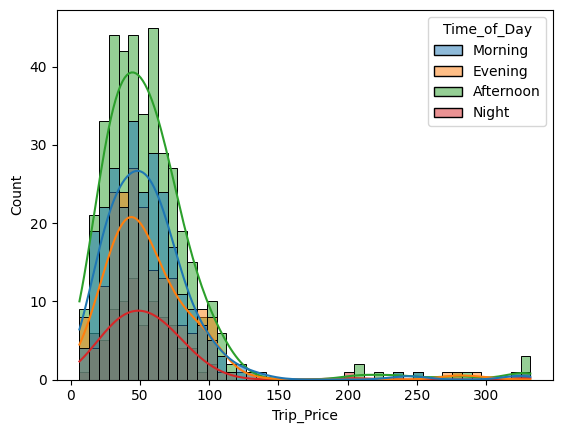

In [78]:
sns.histplot(x = 'Trip_Price', data = df, kde = True, hue = 'Time_of_Day')

<Axes: xlabel='Trip_Price', ylabel='Count'>

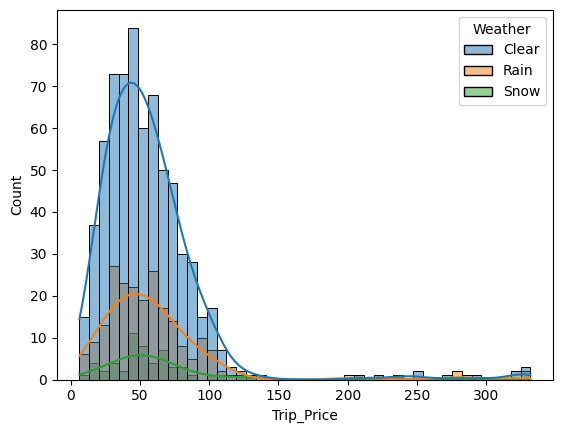

In [79]:
sns.histplot(x = 'Trip_Price', data = df, kde = True, hue = 'Weather')

## Encoding

In [80]:
def labelencoding(df, col):
  LE = LabelEncoder()
  df[col] = LE.fit_transform(df[col])
  return df

labelencoding(df, 'Weather')
labelencoding(df, 'Traffic_Conditions')
labelencoding(df, 'Time_of_Day')
labelencoding(df, 'Day_of_Week')
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,2,0,3,1,0,3.56,0.80,0.32,53.82,36.2624
1,36.870000,1,1,1,0,0,2.70,1.21,0.15,37.27,52.9032
2,30.330000,1,0,4,1,0,3.48,0.51,0.15,116.81,36.4698
3,27.070547,1,0,3,0,0,2.93,0.63,0.32,22.64,15.6180
4,8.640000,0,1,2,2,0,2.55,1.71,0.48,89.33,60.2028


<Axes: >

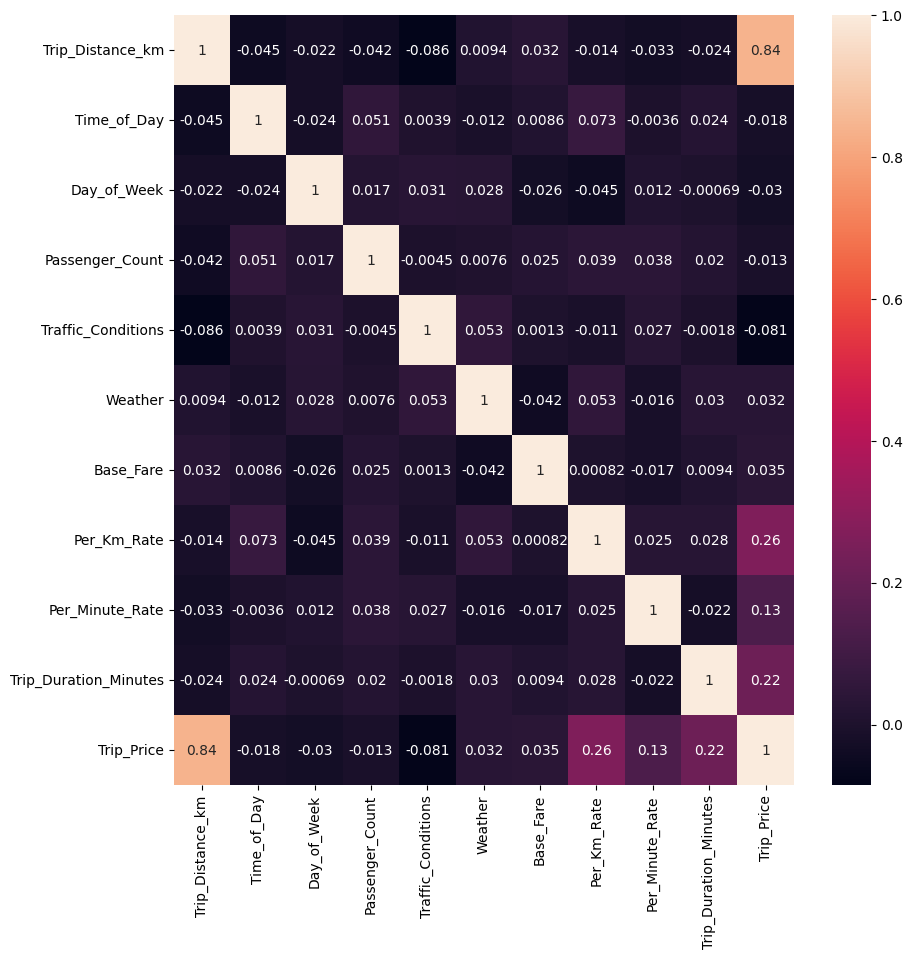

In [81]:
plt.figure(figsize= (10, 10))
sns.heatmap(df.corr(), annot = True)

## Training Model

In [83]:
# Dividing data int inputs and target
X = df.drop(['Trip_Price'], axis = 1)
y = df["Trip_Price"]

In [84]:
# splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [85]:
#scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [86]:
# model training
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [87]:
ypred = model.predict(X_test)
ypred

array([ 4.60691749e+01,  1.07997507e+02,  1.07727307e+00,  4.33919404e+01,
        6.74056553e+01,  4.45316233e+01,  2.60844072e+01,  4.40078638e+01,
        2.48717936e+01,  2.62888654e+01,  4.29198329e+01,  2.52848478e+01,
        6.34767262e+01,  3.33223665e+01,  6.89351341e+01,  9.48141830e+01,
        8.35447407e+01,  3.19944333e+01,  4.69927126e+01, -2.30344689e+00,
        4.03117876e+01,  5.35045718e+01,  7.14065684e+01,  6.57271195e+01,
        1.35337327e+01,  4.49565236e+01,  6.93042292e+01,  6.41633276e+01,
        7.14798680e+01,  8.79295396e+01,  6.65613922e+01,  5.67675828e+01,
        1.03661766e+02,  7.46677453e+01,  7.88691854e+00,  4.03644575e+01,
        7.64652863e+01,  7.62989034e+01,  4.29986653e+01,  2.76696443e+01,
        9.80115703e+01,  3.99756043e-02,  9.97549423e+01,  8.59388565e+01,
        2.84648568e+01,  1.08281373e+02,  7.71894215e+01,  6.95056999e+01,
        6.06055352e+01,  1.66627592e+01,  3.64952034e+01,  6.97648292e+01,
        2.61579117e+02,  

In [88]:
print("metrics:")
r2 = r2_score(y_test, ypred)
print("r2:", r2_score(y_test, ypred))
N = df.shape[0]
P = df.shape[1] - 1
adj_r2 = 1 - (((1-r2**2)*(N-1))/(N-P-1))
print("adj_r2:", adj_r2)
print("MAE:", mean_absolute_error(y_test, ypred))
print("MSE:", mean_squared_error(y_test, ypred))

metrics:
r2: 0.8758163238861916
adj_r2: 0.7645760867300493
MAE: 9.332546121737042
MSE: 236.4460137122455
